# Notebook de Obtención, Limpieza y Transformación de Datos — Fase 2
## Proyecto: Análisis y Predicción de Diabetes
### ¿Qué es un pipeline de preprocesamiento?

Un pipeline de preprocesamiento corresponde a una secuencia estructurada de etapas mediante las cuales los datos en bruto son preparados para su posterior análisis y modelado. Su propósito es garantizar la calidad, consistencia y confiabilidad de la información antes de aplicar técnicas estadísticas o algoritmos de aprendizaje automático.

En este notebook se implementa el siguiente flujo de trabajo:

### Obtención → Exploración → Limpieza → Transformación → Escalamiento → Validación

Cada una de estas etapas se desarrolla mediante funciones reutilizables, favoreciendo la organización del código, la reproducibilidad del proceso y la aplicación consistente de las mismas transformaciones sobre distintos conjuntos de datos.

## Introducción

La diabetes mellitus es una de las enfermedades crónicas más relevantes a nivel mundial y representa un importante desafío para los sistemas de salud debido a sus complicaciones asociadas y su creciente prevalencia. El análisis de datos clínicos permite identificar patrones y factores de riesgo que contribuyen al diagnóstico temprano y a la toma de decisiones informadas.

El conjunto de datos utilizado en este proyecto contiene información médica y demográfica de pacientes, incluyendo variables relacionadas con embarazos, niveles de glucosa, presión arterial, grosor de pliegues cutáneos, niveles de insulina, índice de masa corporal y antecedentes familiares de diabetes. A partir de estos atributos, se busca analizar la calidad de los datos y prepararlos adecuadamente para futuras etapas de modelado predictivo.

## Objetivo General (Fase 2)

Construir un pipeline de preprocesamiento reproducible que permita obtener un conjunto de datos limpio, consistente y preparado para las etapas posteriores de análisis exploratorio y modelado predictivo.

## Objetivos Específicos

* Cargar y explorar el conjunto de datos verificando su estructura, tipos de datos y calidad general.
* Identificar y tratar valores faltantes, inconsistencias y posibles errores de registro.
* Detectar y analizar valores atípicos presentes en las variables numéricas.
* Transformar las variables cuando sea necesario para facilitar su interpretación y procesamiento.
* Estandarizar las variables numéricas para asegurar escalas comparables entre atributos.
* Validar la integridad y consistencia del conjunto de datos resultante.
* Generar una versión procesada del dataset que pueda ser utilizada en etapas posteriores de análisis y modelado.

## Descripción de los Atributos

El dataset contiene las siguientes variables:



<table>
    <thead>
        <tr>
            <th>Variable</th>
            <th>Descripción</th>
        </tr>
    </thead>
    <tbody>
        <tr><td>Pregnancies</td><td>Número de embarazos registrados.</td></tr>
        <tr><td>Glucose</td><td>Concentración de glucosa en plasma.</td></tr>
        <tr><td>BloodPressure</td><td>Presión arterial diastólica (mm Hg).</td></tr>
        <tr><td>SkinThickness</td><td>Grosor del pliegue cutáneo del tríceps (mm).</td></tr>
        <tr><td>Insulin</td><td>Nivel de insulina sérica (mu U/ml).</td></tr>
        <tr><td>BMI</td><td>Índice de Masa Corporal.</td></tr>
        <tr><td>DiabetesPedigreeFunction</td><td>Indicador de predisposición genética a la diabetes.</td></tr>
        <tr><td>Age</td><td>Edad del paciente en años.</td></tr>
        <tr><td>Outcome</td><td>Variable objetivo: 1 indica presencia de diabetes y 0 indica ausencia de diabetes.</td></tr>
    </tbody>
</table>

## Librerías Utilizadas

| Librería | Propósito |
|-----------|-----------|
| numpy | Operaciones numéricas, manejo de arreglos y generación de valores aleatorios para procesos reproducibles. |
| pandas | Carga, exploración y manipulación de datos mediante estructuras DataFrame. |
| matplotlib.pyplot | Generación de gráficos para el análisis exploratorio y la visualización de distribuciones de datos. |
| sklearn.preprocessing | Herramientas para la transformación y preparación de variables antes del modelado. |
| StandardScaler | Estandarización de variables numéricas, ajustando su media a 0 y su desviación estándar a 1. |

### Configuración del entorno

La instrucción **np.random.seed(42)** establece una semilla aleatoria fija para garantizar que cualquier proceso que involucre aleatoriedad produzca siempre los mismos resultados. Esto asegura la **reproducibilidad** del análisis y permite que otros investigadores obtengan los mismos resultados al ejecutar el notebook.

La instrucción **%matplotlib inline** permite que los gráficos generados con Matplotlib se visualicen directamente dentro del notebook, facilitando el análisis y la interpretación de los resultados.

## Resultado esperado de la Fase 2

Al finalizar este notebook, se dispondrá de una versión procesada del dataset denominada diabetes_processed.csv, libre de inconsistencias, con los valores tratados adecuadamente y preparada para las actividades de análisis exploratorio avanzado y construcción de modelos predictivos que se desarrollarán en las siguientes fases del proyecto.

## Importación de librerías

En esta sección se importan las librerías necesarias para la carga, exploración, transformación y visualización de los datos. Además, se configura el entorno para garantizar la reproducibilidad de los resultados y la visualización integrada de gráficos dentro del notebook.

In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib
import sklearn
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler

# Crear el objeto escalador
scaler = StandardScaler()

# Reproducibilidad: fijamos la semilla aleatoria del entorno
np.random.seed(42)

%matplotlib inline

ModuleNotFoundError: No module named 'sklearn'

## Verificación del Entorno de Trabajo

Antes de comenzar el proceso de exploración y transformación de datos, es recomendable registrar las versiones de las principales librerías utilizadas en el proyecto. Esta información permite garantizar la reproducibilidad del análisis y facilita la identificación de posibles diferencias de comportamiento entre distintas versiones de las herramientas empleadas.

En esta sección se muestran las versiones de NumPy, Pandas, Matplotlib y Scikit-Learn utilizadas durante el desarrollo de la Fase 2.

In [2]:

versiones = pd.DataFrame({
    "Componente": [
        "Python",
        "NumPy",
        "Pandas",
        "Matplotlib",
        "Scikit-Learn"
    ],
    "Versión": [
        sys.version.split()[0],
        np.__version__,
        pd.__version__,
        matplotlib.__version__,
        sklearn.__version__
    ]
})

versiones

,Componente,Versión
0,Python,3.12.13
1,NumPy,2.4.6
2,Pandas,3.0.3
3,Matplotlib,3.10.9
4,Scikit-Learn,1.8.0


## 1. Obtención de los datos

### ¿Qué se realiza en esta etapa?

El primer paso del proceso consiste en cargar el conjunto de datos desde un archivo CSV hacia un DataFrame de Pandas. El DataFrame será la estructura principal utilizada durante todo el análisis, ya que permite almacenar, consultar y transformar los datos de manera eficiente.

### ¿Por qué utilizar una función?

La lectura del archivo se encapsula dentro de una función denominada `cargar_datos(ruta)`. Este enfoque favorece la reutilización del código, mejora su organización y facilita el mantenimiento del proyecto. Además, permite centralizar el proceso de carga de datos en un único punto, evitando duplicar instrucciones en distintas partes del notebook.

La función incorpora un mecanismo de control de errores mediante la estructura `try-except`. De esta forma, si el archivo no existe o la ruta especificada es incorrecta, el programa informa al usuario mediante un mensaje claro y comprensible, evitando errores técnicos que puedan dificultar el diagnóstico del problema.

### Descripción del funcionamiento

La función recibe como parámetro la ubicación del archivo (`ruta`) y utiliza el método `pd.read_csv()` para cargar el contenido del dataset en un DataFrame. Posteriormente, se muestra información básica sobre el conjunto de datos cargado, específicamente el número de filas y columnas mediante el atributo `shape`.

Esta verificación inicial permite confirmar que el archivo fue leído correctamente y que las dimensiones coinciden con las esperadas. Finalmente, la función retorna el DataFrame para que pueda ser utilizado en las siguientes etapas del pipeline de preprocesamiento.

Al ejecutar la instrucción:

`df = cargar_datos("diabetes_raw.csv")`

se invoca la función, se carga el dataset y el resultado queda almacenado en la variable `df`, que será utilizada durante todo el proceso de exploración, limpieza y transformación de datos.

### Carga del conjunto de datos

El dataset utilizado en este proyecto se encuentra almacenado en la carpeta `data/raw`, siguiendo la estructura definida durante la Fase 1. Para acceder al archivo desde el notebook de la Fase 2 se utiliza una ruta relativa, lo que facilita la portabilidad del proyecto entre distintos equipos y entornos de desarrollo.

La función `cargar_datos()` lee el archivo `diabetes_raw.csv`, verifica su existencia y carga la información en un DataFrame de Pandas. Una vez completada la lectura, se muestran las dimensiones del conjunto de datos como una validación inicial del proceso de carga.

In [3]:
def cargar_datos(ruta):
    """
    Carga el conjunto de datos desde un archivo CSV.

    Parametros
    ----------
    ruta : str
        Ruta al archivo CSV de entrada.

    Retorna
    -------
    pd.DataFrame
        Datos cargados en un DataFrame.

    Lanza
    -----
    FileNotFoundError
        Si la ruta indicada no existe.
    """
    try:
        df = pd.read_csv(ruta, sep=';')
    except FileNotFoundError:
        raise FileNotFoundError(
            f"No se encontró el archivo '{ruta}'. "
            "Verifica que el CSV exista en la ruta especificada."
        )

    print(f"Datos cargados: {df.shape[0]} filas y {df.shape[1]} columnas.")
    return df


df = cargar_datos("../data/raw/diabetes_raw.csv")

Datos cargados: 2045 filas y 9 columnas.


### Visualización inicial del conjunto de datos

Una vez cargado el dataset, es recomendable visualizar las primeras filas para verificar que la lectura se realizó correctamente. Esta inspección preliminar permite confirmar que los nombres de las columnas son los esperados, que los datos se encuentran correctamente delimitados y que no existen problemas evidentes durante el proceso de importación.

Para ello se utiliza el método `head()`, que muestra por defecto los primeros cinco registros del DataFrame. Esta revisión constituye una validación rápida de la estructura general de los datos antes de iniciar etapas más detalladas de exploración, limpieza y transformación.

### Descripción de la función de carga

La función `cargar_datos()` recibe como parámetro la ruta del archivo CSV y se encarga de realizar la lectura del conjunto de datos mediante la función `pd.read_csv()`. Su objetivo es centralizar el proceso de carga y facilitar la reutilización del código a lo largo del proyecto.

El bloque de texto delimitado por triples comillas (`""" """`) corresponde al *docstring* de la función. Este elemento proporciona documentación interna sobre su propósito, parámetros de entrada, valor de retorno y posibles excepciones, facilitando la comprensión y mantenimiento del código.

La estructura `try-except` implementa un mecanismo de control de errores. Primero intenta leer el archivo especificado; si el archivo no existe o la ruta es incorrecta, se genera una excepción `FileNotFoundError` acompañada de un mensaje descriptivo que orienta al usuario sobre cómo resolver el problema.

Una vez completada la lectura, la función utiliza el atributo `shape` para mostrar las dimensiones del conjunto de datos. El valor `df.shape[0]` representa la cantidad de filas, mientras que `df.shape[1]` indica el número de columnas. Esta información permite verificar rápidamente que la carga se realizó correctamente.

Finalmente, la instrucción `return df` devuelve el DataFrame cargado para que pueda ser utilizado en las siguientes etapas del pipeline de preprocesamiento. Al ejecutar:

`df = cargar_datos("../data/raw/diabetes_raw.csv")`

se invoca la función y el conjunto de datos queda almacenado en la variable `df`, que será utilizada durante todo el proceso de análisis y preparación de los datos.

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,0.0,33.6,0.627,50,1
1,1,85,66,29.0,0.0,26.6,0.351,31,0
2,8,183,64,0.0,0.0,23.3,0.672,32,1
3,1,89,66,NaN,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1


## 2. Exploración Inicial del Conjunto de Datos

### ¿Qué se realiza en esta etapa?

Antes de aplicar cualquier proceso de limpieza o transformación, es fundamental conocer el estado original del conjunto de datos. Esta etapa proporciona una visión general de la información disponible y establece una línea base que permitirá evaluar posteriormente el impacto de las modificaciones realizadas durante el preprocesamiento.

La exploración inicial permite identificar posibles problemas de calidad de datos, comprender la estructura del dataset y determinar qué acciones serán necesarias en las siguientes fases del pipeline.

### Información analizada

La función `explorar_dataframe()` realiza un análisis preliminar del conjunto de datos y reporta los siguientes aspectos:

#### Dimensiones del dataset

Mediante el atributo `shape` se obtiene la cantidad de filas y columnas presentes en el DataFrame. Esta información permite conocer el tamaño del conjunto de datos y verificar que la carga se realizó correctamente.

#### Tipos de datos

A través del atributo `dtypes` se identifican los tipos de datos asociados a cada variable. Este análisis permite distinguir entre variables numéricas y categóricas, información fundamental para seleccionar las técnicas de transformación adecuadas durante el preprocesamiento.

#### Valores faltantes

Utilizando `isnull().sum()`, se calcula la cantidad de valores nulos presentes en cada columna. La detección temprana de datos faltantes permite planificar estrategias de imputación o tratamiento antes de avanzar hacia etapas de modelado.

#### Estadísticos descriptivos

La función `describe()` genera un resumen estadístico de las variables numéricas, incluyendo medidas como cantidad de registros, media, desviación estándar, valores mínimos, máximos y percentiles. Estos indicadores permiten identificar distribuciones inusuales, posibles errores de registro y valores atípicos que podrían afectar el análisis posterior.

### Importancia de la exploración inicial

Realizar una exploración preliminar del dataset es una práctica esencial en cualquier proyecto de Ciencia de Datos. Esta etapa proporciona evidencia objetiva sobre la calidad de los datos y permite tomar decisiones fundamentadas respecto a las tareas de limpieza, transformación y preparación que serán implementadas en las siguientes fases del proyecto.

In [5]:
def explorar_dataframe(df):
    """
    Realiza una exploración inicial del DataFrame.
    """

    print("=" * 60)
    print("DIMENSIONES DEL DATASET")
    print("=" * 60)
    print(df.shape)

    print("\n" + "=" * 60)
    print("TIPOS DE DATOS")
    print("=" * 60)
    print(df.dtypes)

    print("\n" + "=" * 60)
    print("VALORES NULOS")
    print("=" * 60)
    print(df.isnull().sum())

    print("\n" + "=" * 60)
    print("ESTADÍSTICOS DESCRIPTIVOS")
    print("=" * 60)
    print(df.describe())

explorar_dataframe(df)

DIMENSIONES DEL DATASET
(2045, 9)

TIPOS DE DATOS
Pregnancies                   int64
Glucose                       int64
BloodPressure                   str
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

VALORES NULOS
Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               164
Insulin                     245
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

ESTADÍSTICOS DESCRIPTIVOS
       Pregnancies      Glucose  SkinThickness      Insulin          BMI  \
count  2045.000000  2045.000000    1881.000000  1800.000000  2045.000000   
mean      3.888509   126.685575      20.580542    80.673333    32.029526   
std       3.363975    74.365769      16.0

### Resumen de calidad y estructura de las variables

Antes de iniciar las transformaciones del conjunto de datos, es importante realizar una revisión general de cada una de las variables presentes en el DataFrame. Esta inspección permite obtener una visión rápida de la estructura y calidad de los datos, facilitando la identificación de posibles problemas que requieran tratamiento durante el proceso de limpieza.

Para cada columna se analizan los siguientes aspectos:

- **Nombre de la variable:** permite identificar el atributo evaluado.
- **Tipo de dato:** indica cómo Pandas interpreta la información almacenada en la columna (`int64`, `float64`, `object`, entre otros).
- **Cantidad de valores nulos:** muestra el número de registros faltantes que podrían requerir tratamiento.
- **Cantidad de valores únicos:** permite conocer la diversidad de datos presentes en cada variable y detectar posibles inconsistencias o categorías inesperadas.

Esta revisión proporciona una visión general del estado del dataset y constituye una herramienta de diagnóstico útil para definir las estrategias de limpieza y transformación que serán aplicadas en las siguientes etapas del proyecto.

In [6]:
for col in df.columns:
    print(f"\n{'='*50}")
    print(f"Columna: {col}")
    print(f"Tipo: {df[col].dtype}")
    print(f"Nulos: {df[col].isnull().sum()}")
    print(f"Valores únicos: {df[col].nunique()}")


Columna: Pregnancies
Tipo: int64
Nulos: 0
Valores únicos: 19

Columna: Glucose
Tipo: int64
Nulos: 0
Valores únicos: 145

Columna: BloodPressure
Tipo: str
Nulos: 0
Valores únicos: 93

Columna: SkinThickness
Tipo: float64
Nulos: 164
Valores únicos: 55

Columna: Insulin
Tipo: float64
Nulos: 245
Valores únicos: 322

Columna: BMI
Tipo: float64
Nulos: 0
Valores únicos: 1435

Columna: DiabetesPedigreeFunction
Tipo: float64
Nulos: 0
Valores únicos: 806

Columna: Age
Tipo: int64
Nulos: 0
Valores únicos: 55

Columna: Outcome
Tipo: int64
Nulos: 0
Valores únicos: 2


### Revisión de categorías y detección de inconsistencias

Durante la exploración inicial del conjunto de datos, es posible encontrar variables que aparecen clasificadas como tipo `string`, aun cuando por su naturaleza deberían contener valores numéricos. Esta situación suele indicar la presencia de inconsistencias en los datos almacenados dentro de la columna.

Entre las causas más frecuentes se encuentran:

- Valores ingresados con formatos incorrectos.
- Caracteres alfabéticos en campos numéricos.
- Símbolos o caracteres especiales no esperados.
- Espacios en blanco o registros incompletos.
- Valores faltantes representados mediante texto.
- Errores de digitación durante la captura de datos.

Para identificar este tipo de situaciones, se analizan las categorías únicas presentes en cada variable clasificada como `object`, junto con la frecuencia de aparición de cada valor.

Este análisis permite:

- Detectar inconsistencias que afectan la calidad de los datos.
- Identificar registros que requieren limpieza o corrección.
- Determinar si una variable debe mantenerse como categórica o convertirse posteriormente a un tipo numérico.
- Comprender la distribución de los valores presentes en cada columna.
- Definir estrategias de transformación adecuadas para las etapas posteriores del pipeline.

La revisión detallada de los valores únicos constituye una etapa fundamental dentro del proceso de preprocesamiento, ya que permite detectar problemas que no siempre son visibles mediante los estadísticos descriptivos tradicionales.

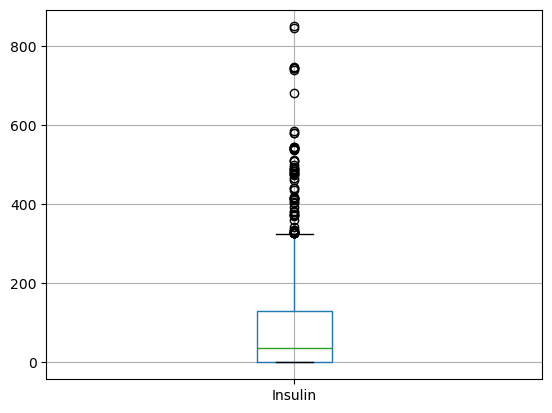

In [7]:
df.boxplot(column='Insulin')
plt.show()

### Análisis de la variable Insulin mediante diagrama de caja

Con el objetivo de comprender mejor el comportamiento de la variable `Insulin`, se generó un diagrama de caja (*boxplot*), herramienta que permite visualizar la distribución de los datos, identificar valores atípicos y evaluar la presencia de posibles anomalías en la variable.

El gráfico evidencia una distribución asimétrica con una marcada concentración de observaciones en valores bajos y una cola extensa hacia valores altos. Este comportamiento indica que la variable presenta una distribución sesgada hacia la derecha, característica habitual en variables biomédicas relacionadas con mediciones fisiológicas.

Asimismo, se observa la presencia de múltiples valores atípicos ubicados sobre el límite superior del diagrama. Sin embargo, estos registros forman parte de la variabilidad natural de la variable y no constituyen necesariamente errores de medición, por lo que no se justifica su eliminación automática.

Durante la exploración inicial también se identificaron valores faltantes en `Insulin`. Considerando que la variable contiene información potencialmente relevante para el análisis de diabetes y que la proporción de datos ausentes es relativamente baja en comparación con el total de registros disponibles, se decidió conservar la variable dentro del conjunto de datos.

En lugar de eliminar la columna completa, se optó por eliminar únicamente los registros que presentan valores faltantes en `Insulin`. Esta decisión permite mantener la información aportada por la variable, evitando al mismo tiempo la incorporación de valores estimados que podrían alterar su distribución original.

La estrategia adoptada busca preservar la calidad y representatividad de los datos, manteniendo una variable clínicamente significativa dentro del conjunto de datos y minimizando el riesgo de introducir sesgos derivados de procesos de imputación.

## 3. Limpieza de Datos

### ¿Qué se realiza en esta etapa?

La limpieza de datos tiene como objetivo mejorar la calidad y consistencia del conjunto de datos antes de realizar procesos de transformación y modelado. Durante esta fase se identifican variables con valores faltantes y atributos que podrían afectar la calidad del análisis posterior.

### Eliminación de registros con valores faltantes en Insulin

Durante la exploración inicial se detectó la presencia de valores faltantes en la variable `Insulin`. Debido a la importancia clínica de esta variable y con el fin de evitar la incorporación de valores estimados mediante técnicas de imputación, se optó por eliminar los registros que presentan datos ausentes.

Esta decisión permite conservar únicamente observaciones completas para dicha variable, garantizando que los análisis posteriores se realicen sobre información efectivamente registrada.

### Eliminación de la variable SkinThickness

La variable `SkinThickness` fue eliminada del conjunto de datos debido a los problemas de calidad detectados durante la exploración inicial. Mantener atributos con información limitada o de baja calidad puede afectar negativamente los análisis posteriores y aumentar la complejidad del proceso de preprocesamiento.

Por esta razón, se decidió excluir esta variable antes de continuar con las etapas de transformación y preparación de los datos.

### Resultado de la limpieza

Una vez aplicadas estas transformaciones, se verifica nuevamente la cantidad de registros disponibles y la presencia de valores faltantes, asegurando que el conjunto de datos se encuentre en condiciones adecuadas para continuar con las siguientes etapas del pipeline de preprocesamiento.

In [9]:
# Cantidad de registros antes de la limpieza
print(f"Filas antes de la limpieza: {len(df)}")

#generamos df_original para realizar la comparacion
df_original = df

# Eliminar registros con valores nulos en Insulin
df = df.dropna(subset=['Insulin'])

# Eliminar la columna SkinThickness
df = df.drop(columns=['SkinThickness'])

# Cantidad de registros después de la limpieza
print(f"Filas después de la limpieza: {len(df)}")

# Verificación
print("\nValores nulos restantes:")
print(df.isnull().sum())

Filas antes de la limpieza: 2045
Filas después de la limpieza: 1800

Valores nulos restantes:
Pregnancies                 0
Glucose                     0
BloodPressure               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
filas_originales = len(df_original)
filas_finales = len(df)

resumen_limpieza = pd.DataFrame({
    "Métrica": [
        "Registros originales",
        "Registros eliminados por valores nulos en Insulin",
        "Registros finales",
        "Columnas originales",
        "Columnas eliminadas (SkinThickness)",
        "Columnas finales"
    ],
    "Cantidad": [
        filas_originales,
        filas_originales - filas_finales,
        filas_finales,
        df_original.shape[1],
        1,
        df.shape[1]
    ]
})

resumen_limpieza

,Métrica,Cantidad
0,Registros originales,2045
1,Registros eliminados por valores nulos en Insulin,245
2,Registros finales,1800
3,Columnas originales,9
4,Columnas eliminadas (SkinThickness),1
5,Columnas finales,8


## 4. Validación Posterior a la Limpieza

### ¿Por qué realizar una nueva validación?

Una vez aplicadas las transformaciones de limpieza, es necesario verificar nuevamente la calidad del conjunto de datos. Este proceso permite confirmar que las acciones realizadas produjeron los resultados esperados y que el dataset se encuentra en condiciones adecuadas para continuar con las etapas de transformación y preparación de variables.

La validación posterior a la limpieza tiene como objetivo identificar posibles inconsistencias remanentes, verificar la ausencia de valores faltantes y confirmar que los tipos de datos sean coherentes con la naturaleza de cada variable.

### Aspectos revisados

Durante esta etapa se realiza una nueva inspección de cada columna considerando:

- Tipo de dato asignado por Pandas.
- Cantidad de valores faltantes.
- Cantidad de valores únicos.
- Posibles valores inesperados o inconsistentes.
- Coherencia de las variables con respecto a su dominio de datos.

Esta revisión permite comprobar que las modificaciones realizadas durante la limpieza fueron efectivas y proporciona una base confiable para continuar con las siguientes fases del pipeline de preprocesamiento.

In [12]:
# Primero una revisión general
for col in df.columns:
    print(f"\n{'='*50}")
    print(f"Columna: {col}")
    print(f"Tipo: {df[col].dtype}")
    print(f"Nulos: {df[col].isnull().sum()}")
    print(f"Valores únicos: {df[col].nunique()}")


Columna: Pregnancies
Tipo: int64
Nulos: 0
Valores únicos: 18

Columna: Glucose
Tipo: int64
Nulos: 0
Valores únicos: 145

Columna: BloodPressure
Tipo: str
Nulos: 0
Valores únicos: 92

Columna: Insulin
Tipo: float64
Nulos: 0
Valores únicos: 322

Columna: BMI
Tipo: float64
Nulos: 0
Valores únicos: 1302

Columna: DiabetesPedigreeFunction
Tipo: float64
Nulos: 0
Valores únicos: 768

Columna: Age
Tipo: int64
Nulos: 0
Valores únicos: 55

Columna: Outcome
Tipo: int64
Nulos: 0
Valores únicos: 2


In [14]:
# Luego una revisión más profunda de las columnas que aún aparezcan como texto:

columnas_texto = df.select_dtypes(include=['object', 'string']).columns

for col in columnas_texto:
    print(f"\n{'='*60}")
    print(f"ANÁLISIS DE: {col}")
    print(f"{'='*60}")
    print(df[col].value_counts(dropna=False))


ANÁLISIS DE: BloodPressure
BloodPressure
70         98
74         85
72         84
68         78
78         76
           ..
78 mmHg     1
0 mmHg      1
85 mmHg     1
86 mmHg     1
111         1
Name: count, Length: 92, dtype: int64


### Detección de texto en una variable numérica

Durante la revisión de los valores únicos de la variable `BloodPressure`, se identificó la presencia de registros almacenados con formatos inconsistentes. Aunque la mayoría de los valores corresponden a mediciones numéricas de presión arterial diastólica, algunos registros incluyen texto adicional asociado a la unidad de medida.

Por ejemplo, junto a valores como:

- `70`
- `74`
- `85`

también aparecen registros como:

- `78 mmHg`
- `85 mmHg`
- `0 mmHg`

Esta situación genera un problema de calidad de datos, ya que una misma variable contiene simultáneamente valores numéricos y cadenas de texto. Como consecuencia, Pandas interpreta la columna como un tipo de dato `object` en lugar de un tipo numérico (`int64` o `float64`).

Mantener este tipo de inconsistencias puede afectar el análisis posterior, dificultando la realización de cálculos estadísticos, la generación de visualizaciones y la aplicación de algoritmos de aprendizaje automático, los cuales requieren que las variables numéricas se encuentren almacenadas en formatos adecuados.

Por esta razón, antes de continuar con las etapas de transformación y modelado, resulta necesario identificar y corregir estos registros para asegurar la consistencia y homogeneidad de los datos.

### Corrección de la variable BloodPressure

Una vez identificada la presencia de texto dentro de la variable `BloodPressure`, es necesario aplicar un proceso de limpieza que permita recuperar la naturaleza numérica de los datos y garantizar su correcta utilización en las etapas posteriores del análisis.

La inconsistencia detectada corresponde a registros que incluyen la unidad de medida (`mmHg`) junto con el valor numérico. Aunque esta información resulta útil desde una perspectiva descriptiva, su almacenamiento dentro de una columna destinada a contener únicamente números impide que la variable sea interpretada correctamente por las herramientas de análisis.

Para corregir esta situación se realizarán dos acciones:

1. **Eliminar las unidades de medida presentes en los registros inconsistentes.**
   
   Se eliminará el texto `mmHg` de aquellos valores que lo contengan, conservando únicamente el valor numérico correspondiente.

2. **Convertir la columna a un tipo de dato numérico.**
   
   Una vez eliminados los textos, se transformará la variable a formato numérico utilizando las herramientas proporcionadas por Pandas. Este paso permitirá realizar cálculos estadísticos, análisis exploratorios y procesos de modelado sin inconvenientes derivados de tipos de datos incorrectos.

Al finalizar la corrección, todos los registros de la variable `BloodPressure` estarán almacenados de manera homogénea y la columna podrá ser interpretada correctamente como una variable cuantitativa continua, mejorando la calidad y consistencia del conjunto de datos.

In [15]:
# Eliminación de la unidad de medida
df['BloodPressure'] = (
    df['BloodPressure']
    .astype(str)
    .str.replace(' mmHg', '', regex=False)
)

# Conversión a tipo numérico
df['BloodPressure'] = pd.to_numeric(
    df['BloodPressure'],
    errors='coerce'
)

# Verificación
print(df['BloodPressure'].dtype)
print(df['BloodPressure'].isnull().sum())

float64
16


### Validación de la corrección aplicada

Una vez completado el proceso de limpieza sobre la variable `BloodPressure`, se realiza una nueva revisión de la estructura del conjunto de datos con el objetivo de verificar que la transformación fue aplicada correctamente.

Esta validación permite comprobar que la columna ya no contiene texto asociado a las unidades de medida y que todos sus registros pueden ser interpretados como valores numéricos. Como resultado, la variable pasa de ser clasificada como tipo `object` a un tipo numérico (`int64` o `float64`), quedando disponible para análisis estadísticos, visualizaciones y procesos de modelado.

Además, se realiza una nueva inspección de todas las variables del dataset para verificar:

- El tipo de dato actual de cada columna.
- La cantidad de valores faltantes existentes.
- La cantidad de valores únicos registrados.
- La consistencia general de los datos después de la limpieza.

Esta etapa constituye una validación de calidad posterior a las transformaciones realizadas y permite asegurar que el conjunto de datos mantiene una estructura adecuada para continuar con las siguientes fases del pipeline de preprocesamiento.

### Resultados obtenidos

La revisión muestra que las variables que originalmente presentaban inconsistencias han sido corregidas y que las columnas numéricas se encuentran almacenadas utilizando tipos de datos apropiados.

De esta manera, el dataset presenta una estructura más homogénea, facilitando la aplicación de técnicas de análisis exploratorio, detección de valores atípicos, escalamiento y modelado predictivo.

In [16]:
for col in df.columns:
    print(f"\n{'='*50}")
    print(f"Columna: {col}")
    print(f"Tipo: {df[col].dtype}")
    print(f"Nulos: {df[col].isnull().sum()}")
    print(f"Valores únicos: {df[col].nunique()}")


Columna: Pregnancies
Tipo: int64
Nulos: 0
Valores únicos: 18

Columna: Glucose
Tipo: int64
Nulos: 0
Valores únicos: 145

Columna: BloodPressure
Tipo: float64
Nulos: 16
Valores únicos: 78

Columna: Insulin
Tipo: float64
Nulos: 0
Valores únicos: 322

Columna: BMI
Tipo: float64
Nulos: 0
Valores únicos: 1302

Columna: DiabetesPedigreeFunction
Tipo: float64
Nulos: 0
Valores únicos: 768

Columna: Age
Tipo: int64
Nulos: 0
Valores únicos: 55

Columna: Outcome
Tipo: int64
Nulos: 0
Valores únicos: 2


### Resumen de calidad de datos posterior a la limpieza

Tras aplicar las correcciones necesarias sobre las variables que presentaban inconsistencias, se realiza una nueva evaluación del conjunto de datos con el propósito de verificar el resultado de las transformaciones efectuadas.

Esta revisión permite confirmar que las acciones de limpieza fueron exitosas y que las variables poseen una estructura adecuada para continuar con las siguientes etapas del proceso de análisis.

Para cada columna se examinan los siguientes aspectos:

- **Tipo de dato:** verifica que cada variable se encuentre almacenada utilizando el formato más apropiado según su naturaleza.
- **Cantidad de valores nulos:** permite comprobar que los registros faltantes hayan sido tratados correctamente.
- **Cantidad de valores únicos:** facilita la identificación de posibles anomalías, valores inesperados o inconsistencias residuales.
- **Consistencia general de los datos:** valida que las transformaciones realizadas hayan generado una estructura homogénea y coherente.

La validación posterior a la limpieza constituye una etapa fundamental dentro del pipeline de preprocesamiento, ya que proporciona evidencia objetiva de que el conjunto de datos cumple con los requisitos mínimos de calidad para continuar con tareas de análisis exploratorio, detección de valores atípicos, escalamiento de variables y construcción de modelos predictivos.

### Resultados obtenidos

La revisión evidencia que las variables previamente afectadas por inconsistencias han sido corregidas exitosamente y que los atributos numéricos se encuentran almacenados utilizando tipos de datos apropiados para su procesamiento.

Como resultado, el conjunto de datos presenta una estructura más consistente, homogénea y preparada para las etapas posteriores del proyecto de ciencia de datos.

## 5. Validación de Rangos y Consistencia de Variables Numéricas

### ¿Por qué validar los rangos de los datos?

Aunque las variables ya se encuentran almacenadas utilizando tipos de datos numéricos adecuados, aún es posible que existan valores que no sean coherentes con el dominio del problema. Estos registros pueden originarse por errores de digitación, problemas durante la captura de datos o inconsistencias presentes en la fuente original.

Por esta razón, se realiza una validación de rangos sobre las variables numéricas más relevantes del conjunto de datos.

### Variables evaluadas

Las siguientes variables deben contener valores positivos:

| Variable | Restricción esperada |
|-----------|---------------------|
| Pregnancies | ≥ 0 |
| Glucose | > 0 |
| BloodPressure | > 0 |
| Insulin | > 0 |
| BMI | > 0 |
| DiabetesPedigreeFunction | > 0 |
| Age | > 0 |

La detección de valores fuera de estos rangos permite identificar posibles inconsistencias que podrían afectar la calidad del análisis y del modelado posterior.

In [18]:
resumen_rangos = pd.DataFrame({
    "Variable": variables_numericas,
    "Valores <= 0": [
        (df[col] <= 0).sum()
        for col in variables_numericas
    ]
})

resumen_rangos

,Variable,Valores <= 0
0,Pregnancies,246
1,Glucose,13
2,BloodPressure,63
3,Insulin,634
4,BMI,16
5,DiabetesPedigreeFunction,0
6,Age,0


### Interpretación de los resultados

La validación de rangos permitió identificar variables que contienen valores iguales o inferiores a cero. Si bien algunos de estos registros son válidos, como ocurre con la variable `Pregnancies`, en otros casos corresponden a mediciones fisiológicas que no pueden tomar valores nulos dentro de un contexto clínico normal.

Las variables `Glucose`, `BloodPressure`, `Insulin` y `BMI` presentan registros con valor cero, situación que podría indicar datos faltantes, errores de captura o mediciones no registradas. Debido a que estos valores no son coherentes con el dominio del problema, será necesario evaluar su tratamiento durante las etapas posteriores del preprocesamiento.

Por otro lado, las variables `DiabetesPedigreeFunction` y `Age` no presentan valores fuera de los rangos esperados, por lo que no se detectaron inconsistencias evidentes en estas columnas.


### Análisis de valores iguales a cero en la variable Insulin

Durante la validación de rangos se identificó una cantidad considerable de registros con valor igual a cero en la variable `Insulin`. Este hallazgo requiere una revisión específica, ya que la interpretación de estos valores puede tener un impacto significativo en la calidad del conjunto de datos y en los resultados obtenidos durante el modelado.

La variable `Insulin` representa el nivel de insulina sérica medido en unidades fisiológicas. Desde una perspectiva clínica, un valor de insulina igual a cero es poco frecuente y, en la mayoría de los casos, suele asociarse a mediciones no registradas, datos faltantes o valores utilizados como marcador para indicar ausencia de información.

Por esta razón, los valores iguales a cero no deben interpretarse automáticamente como mediciones válidas, sino que requieren un análisis adicional para determinar si representan observaciones reales o posibles inconsistencias en el proceso de captura de datos.

La importancia de esta revisión radica en que una alta proporción de valores iguales a cero puede afectar la distribución de la variable, alterar medidas estadísticas como la media y la mediana, e influir en el comportamiento de los modelos predictivos. Además, si estos registros corresponden efectivamente a datos faltantes, tratarlos como valores numéricos reales podría generar conclusiones erróneas durante el análisis.

Por ello, antes de aplicar cualquier técnica de transformación o modelado, resulta necesario cuantificar la cantidad de registros con valor cero y evaluar su impacto sobre la calidad de la información disponible. Este análisis permitirá definir una estrategia de tratamiento adecuada, ya sea mediante imputación, exclusión de registros o eliminación de la variable, dependiendo de la magnitud del problema detectado.

La evaluación de estos valores constituye una etapa fundamental dentro del proceso de limpieza de datos, ya que contribuye a garantizar que las decisiones tomadas durante el preprocesamiento estén respaldadas por evidencia objetiva y criterios metodológicos consistentes.

### Tratamiento de valores inconsistentes detectados en variables numéricas

La validación de rangos permitió identificar la presencia de valores iguales a cero en algunas variables que representan mediciones fisiológicas. Desde una perspectiva clínica, ciertos atributos no pueden adoptar valores nulos dentro de condiciones normales, por lo que estos registros podrían corresponder a datos faltantes, errores de captura o mediciones no registradas.

Las variables que presentan esta situación son:

- `Glucose`
- `BloodPressure`
- `BMI`
- `Insulin`

Antes de continuar con las etapas de detección de valores atípicos y escalamiento, resulta necesario evaluar y corregir estas inconsistencias para asegurar la calidad de la información utilizada en el análisis.

### Estrategia de tratamiento

El procedimiento se desarrollará en varias etapas:

1. **Cuantificar la magnitud del problema**
   
   Se calculará la cantidad y el porcentaje de registros con valores iguales a cero para cada variable afectada. Esto permitirá dimensionar el impacto de las inconsistencias sobre el conjunto de datos.

2. **Evaluar la naturaleza de los valores detectados**
   
   En variables como `Glucose`, `BloodPressure` y `BMI`, un valor igual a cero no resulta fisiológicamente posible, por lo que dichos registros serán considerados como valores faltantes implícitos.

3. **Analizar específicamente la variable Insulin**
   
   Debido a la elevada cantidad de registros con valor cero observada durante la exploración inicial, se realizará una evaluación particular de esta variable para determinar si su calidad permite conservarla dentro del conjunto de datos o si requiere una estrategia de tratamiento diferente.

4. **Transformar los valores inconsistentes**
   
   Los valores identificados como inconsistentes serán convertidos a valores nulos (`NaN`) para facilitar su posterior tratamiento mediante técnicas de imputación o mediante decisiones específicas de limpieza según corresponda.

5. **Validar nuevamente el resultado**
   
   Una vez aplicadas las transformaciones, se verificará nuevamente la calidad del conjunto de datos para asegurar que las inconsistencias detectadas hayan sido correctamente gestionadas.

La aplicación de este procedimiento permitirá disponer de un conjunto de datos más consistente y representativo, reduciendo el riesgo de introducir sesgos o errores durante las etapas posteriores de análisis y modelado predictivo.

## 5.1 Tratamiento de Valores Inconsistentes

### Evaluación de valores iguales a cero en variables numéricas

Durante la validación de rangos se identificó la presencia de valores iguales a cero en algunas variables numéricas. Si bien en ciertos casos estos valores pueden ser válidos, en otras variables representan mediciones fisiológicas para las cuales un valor nulo no resulta coherente desde un punto de vista clínico.

Antes de aplicar cualquier corrección, es necesario cuantificar la magnitud de este problema y determinar el impacto que podría tener sobre la calidad del conjunto de datos.

Particularmente, la variable `Insulin` requiere una evaluación detallada debido a la cantidad de registros con valor igual a cero observados durante la exploración inicial.

In [22]:
ceros_insulin = (df['Insulin'] == 0).sum()

porcentaje_ceros = (ceros_insulin / len(df)) * 100

print(f"Cantidad de ceros: {ceros_insulin}")
print(f"Porcentaje de ceros: {porcentaje_ceros:.2f}%")

Cantidad de ceros: 634
Porcentaje de ceros: 35.22%


### Criterios para la toma de decisiones

Una vez calculado el porcentaje de registros con valor igual a cero en la variable `Insulin`, es posible evaluar la calidad de la información disponible y definir una estrategia de tratamiento adecuada.

Los criterios considerados son los siguientes:

| Porcentaje de valores cero | Interpretación | Acción recomendada |
|---------------------------|----------------|-------------------|
| Menor al 20% | Impacto bajo sobre la variable | Mantener la variable y evaluar imputación |
| Entre 20% y 50% | Calidad moderada | Analizar cuidadosamente la conveniencia de imputar |
| Entre 50% y 70% | Calidad reducida | Evaluar la utilidad de la variable para el análisis |
| Mayor al 70% | Calidad insuficiente | Considerar la eliminación de la variable |

Estos umbrales permiten fundamentar las decisiones de limpieza utilizando criterios objetivos y respaldados por la calidad observada en los datos.

### Comparación de inconsistencias entre variables numéricas

Para complementar el análisis, se realiza una evaluación conjunta de todas las variables numéricas del conjunto de datos. El objetivo es identificar cuáles presentan la mayor cantidad de valores potencialmente inconsistentes y determinar si el problema observado en `Insulin` también afecta a otros atributos.

La siguiente tabla resume la cantidad y el porcentaje de registros con valores menores o iguales a cero para cada variable analizada.

Esta información permite comparar la calidad relativa de las variables y proporciona evidencia objetiva para justificar las decisiones de limpieza que serán aplicadas posteriormente.

variables_numericas = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

resumen_calidad = pd.DataFrame({
    "Variable": variables_numericas,
    "Valores <= 0": [
        (df[col] <= 0).sum()
        for col in variables_numericas
    ],
    "Porcentaje (%)": [
        round((df[col] <= 0).sum() / len(df) * 100, 2)
        for col in variables_numericas
    ]
})

resumen_calidad.sort_values(
    by="Porcentaje (%)",
    ascending=False
)

In [25]:
variables_numericas = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

resumen_calidad = pd.DataFrame({
    "Variable": variables_numericas,
    "Valores <= 0": [
        (df[col] <= 0).sum()
        for col in variables_numericas
    ],
    "Porcentaje (%)": [
        round((df[col] <= 0).sum() / len(df) * 100, 2)
        for col in variables_numericas
    ]
})

resumen_calidad.sort_values(
    by="Porcentaje (%)",
    ascending=False
)

,Variable,Valores <= 0,Porcentaje (%)
3,Insulin,634,35.22
0,Pregnancies,246,13.67
2,BloodPressure,63,3.50
4,BMI,16,0.89
1,Glucose,13,0.72
5,DiabetesPedigreeFunction,0,0.00
6,Age,0,0.00


### Transformación de valores inconsistentes

El análisis realizado permitió identificar variables cuyos valores iguales a cero no son compatibles con el significado clínico de la medición registrada.

En las variables `Glucose`, `BloodPressure` y `BMI`, un valor igual a cero no representa una condición fisiológica posible, por lo que estos registros serán tratados como valores faltantes implícitos.

Para facilitar su tratamiento posterior, dichos valores serán convertidos a nulos (`NaN`). Esta transformación permite utilizar posteriormente técnicas de imputación basadas en medidas estadísticas representativas de cada variable.

La variable `Insulin` será analizada de forma independiente debido a la elevada proporción de registros con valor cero observada durante la etapa anterior.

In [27]:
df['Glucose'] = df['Glucose'].replace(0, np.nan)

df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)

df['BMI'] = df['BMI'].replace(0, np.nan)

### Validación de valores faltantes generados

Una vez realizada la conversión de los valores inconsistentes a nulos, se efectúa una nueva revisión del conjunto de datos con el fin de cuantificar la cantidad de registros faltantes presentes en cada variable.

Esta validación permite determinar el impacto de las transformaciones aplicadas y proporciona la información necesaria para seleccionar una estrategia de imputación adecuada en las siguientes etapas del preprocesamiento.

In [28]:
print(df.isnull().sum())

Pregnancies                  0
Glucose                     13
BloodPressure               79
Insulin                      0
BMI                         16
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64


### Evaluación de estrategias de imputación

Conocida la cantidad de valores faltantes presentes en cada variable, se procederá a evaluar la aplicación de técnicas de imputación.

Debido a que las variables analizadas presentan distribuciones asimétricas y contienen valores atípicos, la mediana constituye una alternativa adecuada para reemplazar los registros faltantes, ya que es menos sensible a valores extremos que la media aritmética.

La decisión final de imputar o eliminar una variable dependerá de la proporción de valores faltantes observada y de la relevancia que dicha variable posea para los objetivos del proyecto.

### Próximos pasos del proceso de preprocesamiento

Una vez completado el tratamiento de valores inconsistentes, el conjunto de datos continuará avanzando por las siguientes etapas del pipeline de preparación:

1. Detección y análisis de valores atípicos mediante diagramas de caja (*boxplots*).
2. Identificación de outliers utilizando el método del rango intercuartílico (IQR).
3. Aplicación de técnicas de escalamiento mediante `StandardScaler`.
4. Validación final del conjunto de datos procesado.

Estas actividades permitirán obtener un dataset limpio, consistente y preparado para las fases posteriores de análisis exploratorio y modelado predictivo.

In [31]:
df.isnull().sum()

Pregnancies                  0
Glucose                     13
BloodPressure               79
Insulin                      0
BMI                         16
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

In [32]:
variables_imputar = [
    'Glucose',
    'BloodPressure',
    'BMI'
]

for col in variables_imputar:

    mediana = df[col].median()

    df[col] = df[col].fillna(mediana)

    print(
        f"{col}: imputado con mediana = {mediana:.2f}"
    )

Glucose: imputado con mediana = 119.00
BloodPressure: imputado con mediana = 72.00
BMI: imputado con mediana = 32.10


In [33]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 7. Detección y Análisis de Valores Atípicos

### ¿Qué son los valores atípicos?

Los valores atípicos (*outliers*) son observaciones que se encuentran significativamente alejadas del comportamiento general de los datos. Estos registros pueden originarse por errores de captura, problemas de medición o simplemente representar casos poco frecuentes dentro de la población analizada.

La identificación de valores atípicos es una etapa importante dentro del preprocesamiento de datos, ya que su presencia puede influir sobre medidas estadísticas como la media y la desviación estándar, además de afectar el rendimiento de algunos algoritmos de aprendizaje automático.

### Estrategia de análisis

Para evaluar la presencia de valores atípicos se utilizarán diagramas de caja (*boxplots*), una herramienta gráfica que permite visualizar:

- La mediana de la distribución.
- Los cuartiles de los datos.
- La dispersión de los valores.
- Posibles observaciones alejadas del comportamiento general.

El objetivo de este análisis no es eliminar automáticamente los valores detectados, sino comprender la distribución de las variables y determinar si los registros observados representan errores o características propias de la población estudiada.

### Visualización de distribuciones mediante diagramas de caja

A continuación, se genera un diagrama de caja para cada variable numérica del conjunto de datos.

La interpretación de estos gráficos permitirá identificar variables con distribuciones asimétricas, alta dispersión o presencia de observaciones potencialmente atípicas.

Los resultados obtenidos servirán como base para complementar el análisis estadístico utilizando posteriormente el método del rango intercuartílico (IQR).

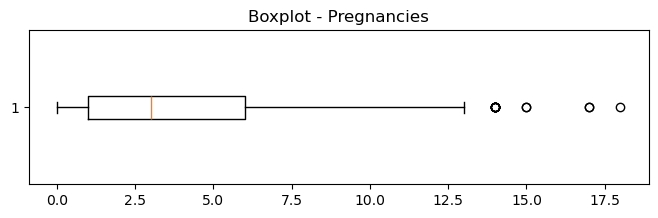

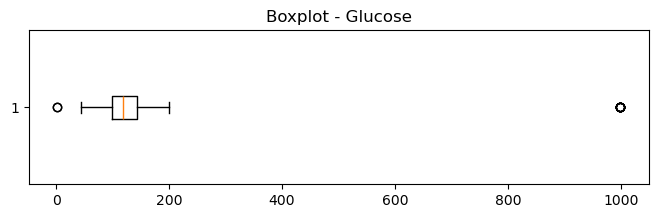

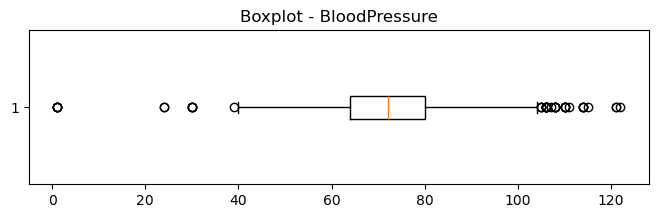

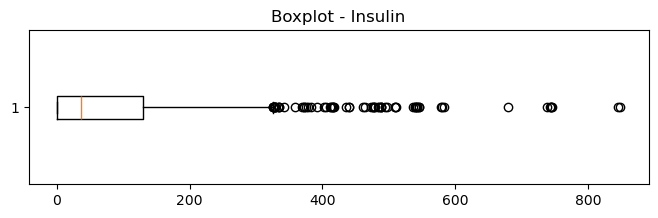

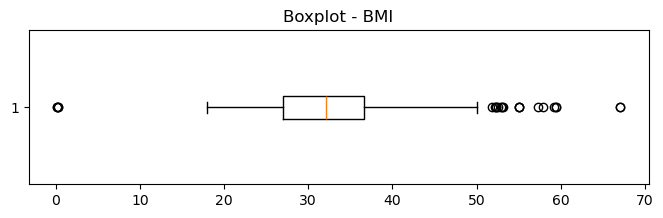

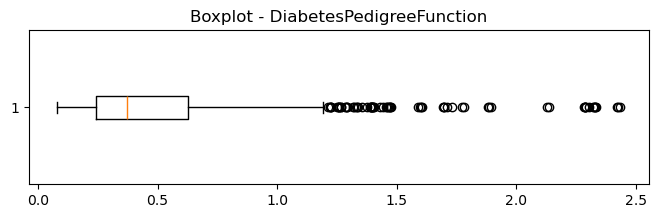

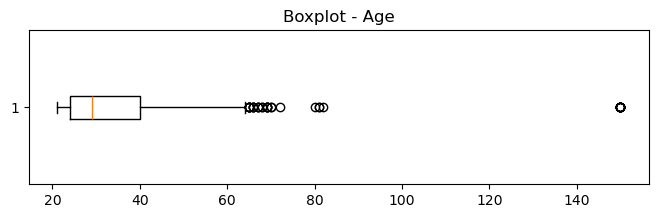

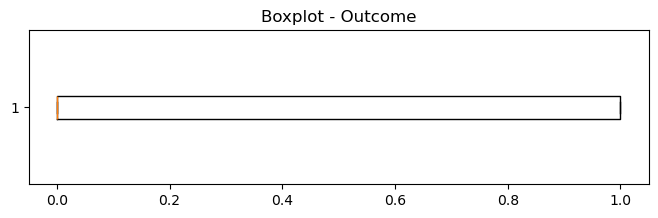

In [37]:
columnas_numericas = df.select_dtypes(
    include=['int64', 'float64']
).columns

for col in columnas_numericas:

    plt.figure(figsize=(8, 2))

    plt.boxplot(df[col], vert=False)

    plt.title(f'Boxplot - {col}')

    plt.show()

## 7.1 Identificación de Valores Atípicos mediante el Método IQR

Aunque los diagramas de caja permiten detectar visualmente la presencia de observaciones extremas, resulta conveniente complementar este análisis mediante una técnica cuantitativa.

Para ello se utilizará el método del rango intercuartílico (*Interquartile Range - IQR*), ampliamente utilizado en análisis exploratorio de datos para identificar valores potencialmente atípicos.

### ¿Cómo funciona el método IQR?

El procedimiento calcula:

- Primer cuartil (Q1).
- Tercer cuartil (Q3).
- Rango intercuartílico (IQR = Q3 − Q1).

Posteriormente se establecen límites de referencia:

- Límite inferior = Q1 − 1.5 × IQR
- Límite superior = Q3 + 1.5 × IQR

Cualquier observación que se encuentre fuera de estos límites será considerada un posible valor atípico.

Este análisis permite cuantificar objetivamente la cantidad de registros extremos presentes en cada variable numérica.

In [38]:
resumen_outliers = []

for col in columnas_numericas:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    cantidad = (
        ((df[col] < li) | (df[col] > ls))
    ).sum()

    resumen_outliers.append(
        [col, cantidad]
    )

pd.DataFrame(
    resumen_outliers,
    columns=['Variable', 'Cantidad de Outliers']
).sort_values(
    by='Cantidad de Outliers',
    ascending=False
)

,Variable,Cantidad de Outliers
5,DiabetesPedigreeFunction,71
3,Insulin,67
2,BloodPressure,45
6,Age,41
4,BMI,22
0,Pregnancies,15
1,Glucose,12
7,Outcome,0


### Interpretación de los resultados

La tabla generada muestra la cantidad de observaciones identificadas como valores atípicos para cada variable numérica.

Es importante señalar que la detección de un valor atípico no implica necesariamente que dicho registro sea incorrecto o deba eliminarse. En conjuntos de datos clínicos y biomédicos es habitual encontrar observaciones extremas que representan condiciones reales de algunos pacientes.

Por esta razón, los resultados obtenidos deben interpretarse considerando el contexto del problema y el significado de cada variable, evitando eliminar información potencialmente relevante sin una justificación técnica adecuada.

## 8. Escalamiento de Variables

### ¿Por qué es necesario escalar los datos?

Las variables del conjunto de datos se encuentran expresadas en diferentes unidades de medida y presentan rangos de valores considerablemente distintos.

Por ejemplo:

- La edad se expresa en años.
- La glucosa corresponde a una concentración plasmática.
- El índice de masa corporal utiliza una escala diferente.
- La función de predisposición genética posee valores mucho menores que otras variables.

Estas diferencias pueden provocar que algunas variables tengan una influencia desproporcionada sobre determinados algoritmos de aprendizaje automático.

Para evitar este problema se aplicará una técnica de estandarización denominada **StandardScaler**.

### Estandarización mediante StandardScaler

La técnica StandardScaler transforma cada variable numérica para que posea:

- Media igual a 0.
- Desviación estándar igual a 1.

Esta transformación conserva la información contenida en los datos, pero homogeniza las escalas de todas las variables, facilitando su comparación y mejorando el comportamiento de numerosos algoritmos de aprendizaje automático.

El resultado será un conjunto de datos preparado para las etapas posteriores de análisis y modelado predictivo.

In [41]:
StandardScaler()

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [44]:
columnas_escalar = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

df[columnas_escalar] = scaler.fit_transform(
    df[columnas_escalar]
)

In [45]:
df[columnas_escalar].describe().T[['mean', 'std']]

,mean,std
Pregnancies,-5.723816e-17,1.000278
Glucose,-4.144833e-17,1.000278
BloodPressure,-4.761623e-16,1.000278
BMI,1.914518e-16,1.000278
DiabetesPedigreeFunction,6.908054e-18,1.000278
Age,1.776357e-16,1.000278


### Validación del escalamiento

Una vez aplicada la transformación mediante `StandardScaler`, se verificaron las estadísticas descriptivas de las variables numéricas escaladas.

Los resultados muestran que todas las variables presentan una media muy cercana a cero y una desviación estándar cercana a uno, comportamiento esperado cuando la estandarización ha sido aplicada correctamente.

Las pequeñas diferencias observadas respecto a los valores exactos de 0 y 1 corresponden a errores de precisión numérica inherentes a los cálculos realizados por el computador y no representan un problema para el análisis.

Estos resultados confirman que las variables fueron normalizadas exitosamente, quedando expresadas en una escala común que facilita su utilización en algoritmos de aprendizaje automático y análisis estadísticos posteriores.

## 9. Exportación del Conjunto de Datos Procesado

Una vez completadas las actividades de exploración, limpieza, validación, tratamiento de valores faltantes y escalamiento, se genera una versión final del conjunto de datos preparada para las etapas posteriores del proyecto.

La exportación del dataset permite conservar todas las transformaciones realizadas durante esta fase y garantiza la disponibilidad de una fuente de datos consistente para los análisis y modelos que serán desarrollados en las siguientes etapas.

El archivo será almacenado en la carpeta de datos procesados siguiendo la estructura definida para el proyecto.

In [47]:
ruta_salida = "../data/processed/diabetes_clean.csv"

df.to_csv(
    ruta_salida,
    index=False
)

print(f"Dataset exportado correctamente a: {ruta_salida}")

Dataset exportado correctamente a: ../data/processed/diabetes_clean.csv


## 10. Resumen de la Fase

Durante esta fase se desarrolló un proceso completo de preparación de datos sobre el conjunto de datos de diabetes.

Las principales actividades realizadas fueron:

- Obtención y carga de los datos.
- Exploración inicial de la estructura del dataset.
- Identificación de tipos de datos y valores faltantes.
- Detección y corrección de inconsistencias.
- Análisis de rangos válidos para variables numéricas.
- Tratamiento de valores faltantes mediante imputación.
- Detección y análisis de valores atípicos.
- Estandarización de variables numéricas mediante StandardScaler.
- Generación y almacenamiento del dataset procesado.

Como resultado, se obtuvo un conjunto de datos limpio, consistente y preparado para las etapas posteriores de análisis exploratorio avanzado y modelado predictivo.

## Consideraciones sobre la organización del código

Durante el desarrollo de esta fase se optó por mantener todas las funciones y procedimientos directamente dentro del notebook, en lugar de implementar un directorio `utils` para almacenar funciones auxiliares.

Esta decisión responde principalmente a los objetivos de la fase, los cuales están orientados a documentar y evidenciar de manera clara cada una de las etapas del proceso de obtención, exploración, limpieza y transformación de los datos. Mantener las funciones dentro del mismo notebook facilita la comprensión del flujo de trabajo, permite visualizar de forma secuencial cada transformación aplicada y mejora la trazabilidad de las decisiones tomadas durante el preprocesamiento.

Además, dado que las funciones desarrolladas fueron utilizadas exclusivamente en esta fase y sobre un único conjunto de datos, la creación de módulos externos habría agregado complejidad estructural sin aportar beneficios significativos en términos de reutilización o mantenimiento.

No obstante, a medida que el proyecto avance hacia las etapas de modelado, evaluación y despliegue, será recomendable refactorizar el código y trasladar las funciones reutilizables a un directorio `utils` o implementar una solución basada en Programación Orientada a Objetos (POO). Esto permitirá mejorar la modularidad, facilitar las pruebas, promover la reutilización del código y mantener una arquitectura más escalable para las siguientes fases del proyecto.

Por tanto, la ausencia de un directorio `utils` en esta fase constituye una decisión metodológica orientada a privilegiar la claridad, la trazabilidad y la documentación del proceso de preparación de datos, aspectos fundamentales durante las etapas iniciales de un proyecto de ciencia de datos.